In [4]:
import tensorflow as tf

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np

In [7]:
# caminho para as letras do poema
path = 'files/irish-lyrics-eof.txt'
# lendo os dados
data = open(path).read()

# transformando em uma lista, com cada verso separado como elementos diferentes da lista
corpus = data.lower().split('\n')
corpus

['come all ye maidens young and fair',
 'and you that are blooming in your prime',
 'always beware and keep your garden fair',
 'let no man steal away your thyme',
 'for thyme it is a precious thing',
 'and thyme brings all things to my mind',
 'nlyme with all its flavours, along with all its joys',
 'thyme, brings all things to my mind',
 'once i and a bunch of thyme',
 'i thought it never would decay',
 'then came a lusty sailor',
 'who chanced to pass my way',
 'and stole my bunch of thyme away',
 'the sailor gave to me a rose',
 'a rose that never would decay',
 'he gave it to me to keep me reminded',
 'of when he stole my thyme away',
 'sleep, my child, and peace attend thee',
 'all through the night',
 'guardian angels god will send thee',
 'soft the drowsy hours are creeping',
 'hill and dale in slumber sleeping',
 'i my loving vigil keeping',
 'while the moon her watch is keeping',
 'while the weary world is sleeping',
 'oer thy spirit gently stealing',
 'visions of delight rev

In [8]:
# instanciando o tokenizer
tk = Tokenizer()

# processando o texto
tk.fit_on_texts(corpus)
total_words = len(tk.word_index) + 1

print(tk.word_index)
print(total_words)

{'the': 1, 'and': 2, 'i': 3, 'to': 4, 'a': 5, 'of': 6, 'my': 7, 'in': 8, 'me': 9, 'for': 10, 'you': 11, 'all': 12, 'was': 13, 'she': 14, 'that': 15, 'on': 16, 'with': 17, 'her': 18, 'but': 19, 'as': 20, 'when': 21, 'love': 22, 'is': 23, 'your': 24, 'it': 25, 'will': 26, 'from': 27, 'by': 28, 'they': 29, 'be': 30, 'are': 31, 'so': 32, 'he': 33, 'old': 34, 'no': 35, 'oh': 36, 'ill': 37, 'at': 38, 'one': 39, 'his': 40, 'there': 41, 'were': 42, 'heart': 43, 'down': 44, 'now': 45, 'we': 46, 'where': 47, 'young': 48, 'never': 49, 'go': 50, 'come': 51, 'then': 52, 'did': 53, 'not': 54, 'said': 55, 'away': 56, 'their': 57, 'sweet': 58, 'them': 59, 'green': 60, 'if': 61, 'take': 62, 'our': 63, 'like': 64, 'night': 65, 'day': 66, 'o': 67, 'out': 68, 'fair': 69, 'this': 70, 'town': 71, 'have': 72, 'can': 73, 'true': 74, 'its': 75, 'thou': 76, 'see': 77, 'dear': 78, 'more': 79, 'theres': 80, 'or': 81, 'had': 82, 'would': 83, 'over': 84, 'hear': 85, 'up': 86, 'ive': 87, 'through': 88, 'home': 89, '

In [10]:
# lista que guarda as sequencias de palavras transformadas em numeros para cada verso
input_sequences = []
for line in corpus:
    # transforma o texto da linha em seu valor numérico correspondente
    token_list = tk.texts_to_sequences([line])[0]
    # adiciona as versoes quebradas de uma linha
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

input_sequences

[[51, 12],
 [51, 12, 96],
 [51, 12, 96, 1217],
 [51, 12, 96, 1217, 48],
 [51, 12, 96, 1217, 48, 2],
 [51, 12, 96, 1217, 48, 2, 69],
 [2, 11],
 [2, 11, 15],
 [2, 11, 15, 31],
 [2, 11, 15, 31, 361],
 [2, 11, 15, 31, 361, 8],
 [2, 11, 15, 31, 361, 8, 24],
 [2, 11, 15, 31, 361, 8, 24, 1218],
 [272, 798],
 [272, 798, 2],
 [272, 798, 2, 204],
 [272, 798, 2, 204, 24],
 [272, 798, 2, 204, 24, 579],
 [272, 798, 2, 204, 24, 579, 69],
 [118, 35],
 [118, 35, 119],
 [118, 35, 119, 799],
 [118, 35, 119, 799, 56],
 [118, 35, 119, 799, 56, 24],
 [118, 35, 119, 799, 56, 24, 184],
 [10, 184],
 [10, 184, 25],
 [10, 184, 25, 23],
 [10, 184, 25, 23, 5],
 [10, 184, 25, 23, 5, 580],
 [10, 184, 25, 23, 5, 580, 456],
 [2, 184],
 [2, 184, 800],
 [2, 184, 800, 12],
 [2, 184, 800, 12, 801],
 [2, 184, 800, 12, 801, 4],
 [2, 184, 800, 12, 801, 4, 7],
 [2, 184, 800, 12, 801, 4, 7, 235],
 [1219, 17],
 [1219, 17, 12],
 [1219, 17, 12, 75],
 [1219, 17, 12, 75, 1220],
 [1219, 17, 12, 75, 1220, 236],
 [1219, 17, 12, 75, 1

In [11]:
# pega o tamanho da maior sequencia
max_sequence_len = max([len(x) for x in input_sequences])
# padding das sequencias para formar a matriz
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))
input_sequences

array([[   0,    0,    0, ...,    0,   51,   12],
       [   0,    0,    0, ...,   51,   12,   96],
       [   0,    0,    0, ...,   12,   96, 1217],
       ...,
       [   0,    0,    0, ...,    0,   47,  105],
       [   0,    0,    0, ...,   47,  105,  138],
       [   0,    0,    0, ...,  105,  138,  184]],
      shape=(12038, 16), dtype=int32)

In [12]:
# definindo os valores de X e os de Y
xs, labels = input_sequences[:, :-1], input_sequences[:, -1]
# transformando os valores de Y em um vetor onehot
ys = tf.keras.utils.to_categorical(labels, num_classes=total_words)

In [19]:
# criando a rede neura
model = Sequential()

# adicionando as camadas
model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
model.add(Bidirectional(LSTM(150)))
model.add(Dense(total_words, activation='softmax'))

# definindo o optimizador
adam = Adam(learning_rate=0.01)
# compilando
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

In [20]:
# treinando o modelo
history = model.fit(xs, ys, epochs=100, verbose=1)

Epoch 1/100


W0000 00:00:1781549162.331404    1521 cpu_allocator_impl.cc:82] Allocation of 129528880 exceeds 10% of free system memory.


377/377 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.0733 - loss: 6.6447
Epoch 2/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.1118 - loss: 5.7983
Epoch 3/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.1609 - loss: 5.0114
Epoch 4/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.2280 - loss: 4.0745
Epoch 5/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.3209 - loss: 3.2488
Epoch 6/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.4258 - loss: 2.5806
Epoch 7/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5196 - loss: 2.0723
Epoch 8/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.5971 - loss: 1.7054
Epoch 9/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.6539 - loss: 1.4429
Epoch 10/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.6988 - loss: 1.2615
Epoch 11/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.6857 - loss: 1.2983
Epoch 12/100
377/377 ━━━━━━━━━━

In [21]:
import matplotlib.pyplot as plt

# função para plotar os graficos com historico do treinamento
def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.xlabel('Epochs')
    plt.ylabel(string)
    plt.show()

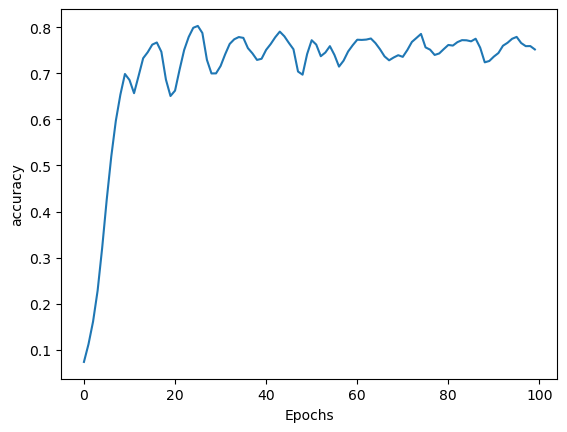

In [22]:
plot_graphs(history, 'accuracy')

In [23]:
# texto inicial
seed_text = "I've got a bad feeling about this"
# quantidade de palavras para prever
next_words = 100

for _ in range(next_words):
    # transforma o texto em tokens
    token_list = tk.texts_to_sequences([seed_text])[0]
    # preenche a lista de tokens
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    # preve a proxima palavra
    predicted = np.argmax(model.predict(token_list), axis=-1)

    # adiciona a palavra prevista no texto
    output_word = ''
    for word, index in tk.word_index.items():
        if index == predicted:
            output_word = word
            break
    seed_text += ' ' + output_word

# mostra o resultado final
print(seed_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━